
# Figure 2 and supplementary feature-importance figures for the ICU mortality manuscript

This notebook reads the CSV outputs created by the model-training notebook and generates:

- **Main Figure 2**: predictive performance and calibration
- **Supplementary Figure S3**: feature-importance support
- **Top-30 feature overlap CSV summaries**

## Notes

- This notebook does **not** retrain models.
- Figures are formatted for manuscript use at **170 mm width**.
- Files are saved as **PNG, PDF, and SVG**.
- The earlier tuning-diagnostics supplementary figure is intentionally omitted.


In [1]:

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.6,
    "figure.titlesize": 10,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


In [2]:

# ============================================================
# 1. Global configuration
# ============================================================

FIGURE_WIDTH_MM = 170
FIGURE_WIDTH_IN = FIGURE_WIDTH_MM / 25.4
MAIN_FIG_HEIGHT_IN = 5.65
SUPP_FIG_HEIGHT_IN = 4.8
SAVE_DPI = 600
TOP_N_OVERLAP = 30

MODEL_ORDER = ["logistic_regression", "xgboost_auc_optimized", "mlp"]
MODEL_LABELS = {
    "logistic_regression": "Logistic Regression",
    "xgboost_auc_optimized": "XGBoost",
    "mlp": "MLP",
}
MODEL_COLORS = {
    "logistic_regression": "#4C78A8",   # muted blue
    "xgboost_auc_optimized": "#C97B30", # paper-style brown-orange
    "mlp": "#5B8C5A",                   # muted green
}
METRIC_COLUMNS = ["roc_auc", "pr_auc", "f1", "brier_score"]
METRIC_LABELS = ["AUROC ↑", "AUPRC ↑", "F1 ↑", "Brier ↓"]

BASE_DIR = Path("..")
RESULTS_DIR_CANDIDATES = [
    BASE_DIR / "output" / "model_training_results",
    Path("../output/model_training_results"),
    Path("./output/model_training_results"),
    Path("/mnt/data/output/model_training_results"),
]
MAIN_FIG_DIR = BASE_DIR / "Figure 2"
SUPP_FIG_DIR = BASE_DIR / "Supplementary Figures"
MAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)
SUPP_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Main figure dir:", MAIN_FIG_DIR.resolve())
print("Supplementary figure dir:", SUPP_FIG_DIR.resolve())


Main figure dir: C:\Users\junse\Documents\research\IUBDC 2026\Figure 2
Supplementary figure dir: C:\Users\junse\Documents\research\IUBDC 2026\Supplementary Figures


In [3]:
# ============================================================
# 2. Helper functions
# ============================================================

def find_results_dir():
    for candidate in RESULTS_DIR_CANDIDATES:
        if candidate.exists() and (candidate / "combined_external_test_performance_summary.csv").exists():
            return candidate
    checked = "\n".join(str(p.resolve()) for p in RESULTS_DIR_CANDIDATES)
    raise FileNotFoundError("Could not find model_training_results. Checked:\n" + checked)


def pretty_model_name(model_name):
    return MODEL_LABELS.get(model_name, model_name)


def panel_label(ax, text):
    ax.text(-0.13, 1.06, text, transform=ax.transAxes, ha="left", va="top", fontsize=10, fontweight="bold")


def style_axis(ax):
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.grid(True, color="#D9D9D9", linewidth=0.5, alpha=0.6)
    ax.set_facecolor("white")


def save_figure(fig, out_dir, stem, dpi=SAVE_DPI):
    png = out_dir / f"{stem}.png"
    pdf = out_dir / f"{stem}.pdf"
    svg = out_dir / f"{stem}.svg"
    fig.savefig(png, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    fig.savefig(svg, bbox_inches="tight", facecolor="white")
    print("Saved:", png)
    print("Saved:", pdf)
    print("Saved:", svg)


def normalize_metric_column(values, higher_is_better=True):
    values = np.asarray(values, dtype=float)
    valid = values[~np.isnan(values)]
    if len(valid) == 0:
        return np.zeros_like(values)
    vmin, vmax = valid.min(), valid.max()
    if np.isclose(vmin, vmax):
        scaled = np.full_like(values, 0.60, dtype=float)
    else:
        scaled = (values - vmin) / (vmax - vmin)
    if not higher_is_better:
        scaled = 1.0 - scaled
    return scaled


def get_top_features(path, value_col, model_name, top_n=TOP_N_OVERLAP):
    df = pd.read_csv(path)
    if value_col not in df.columns:
        raise ValueError(f"Column {value_col} not found in {path.name}")
    df = df.copy().sort_values(by=value_col, ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)
    top = df.head(top_n).copy()
    top["model_name"] = model_name
    top["source_file"] = path.name
    return top


In [4]:

# ============================================================
# 3. Load data tables
# ============================================================

RESULTS_DIR = find_results_dir()
print("Using results dir:", RESULTS_DIR.resolve())

perf_df = pd.read_csv(RESULTS_DIR / "combined_external_test_performance_summary.csv")
roc_df = pd.read_csv(RESULTS_DIR / "combined_roc_curve_points.csv")
pr_df = pd.read_csv(RESULTS_DIR / "combined_precision_recall_curve_points.csv")
cal_df = pd.read_csv(RESULTS_DIR / "combined_calibration_curve_points.csv")

perf_df = perf_df.loc[perf_df["split"] == "external_test"].copy()
for df in [perf_df, roc_df, pr_df, cal_df]:
    df["model"] = df["model"].astype(str)

available_models = [m for m in MODEL_ORDER if m in perf_df["model"].unique()]
print("Available models:", [pretty_model_name(m) for m in available_models])
display(perf_df[["model", "roc_auc", "pr_auc", "f1", "brier_score", "threshold"]])


Using results dir: C:\Users\junse\Documents\research\IUBDC 2026\output\model_training_results
Available models: ['Logistic Regression', 'XGBoost', 'MLP']


,model,roc_auc,pr_auc,f1,brier_score,threshold
0,xgboost_auc_optimized,0.875175,0.584445,0.448037,0.086970,0.50
1,mlp,0.866851,0.546140,0.538996,0.090938,0.31
2,logistic_regression,0.863112,0.548279,0.503123,0.149773,0.50


Saved: ..\Figure 2\Figure2_model_performance_calibration_170mm.png
Saved: ..\Figure 2\Figure2_model_performance_calibration_170mm.pdf
Saved: ..\Figure 2\Figure2_model_performance_calibration_170mm.svg


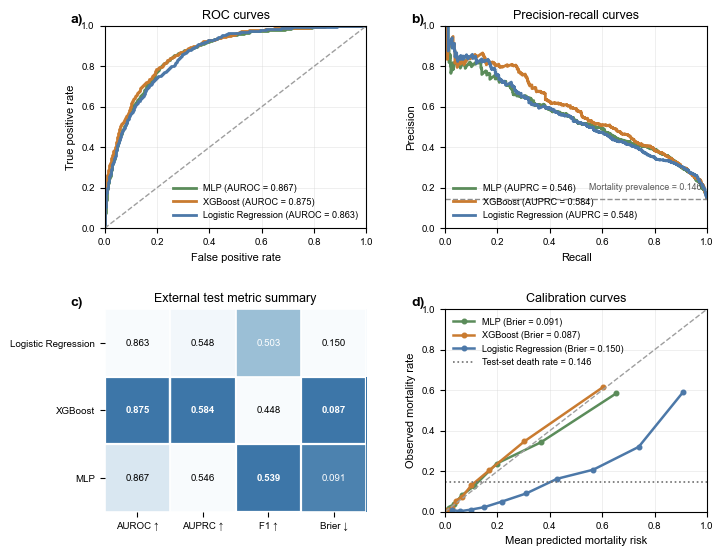

In [5]:

# ============================================================
# 4. Main Figure 2
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH_IN, MAIN_FIG_HEIGHT_IN))
ax_roc, ax_pr = axes[0, 0], axes[0, 1]
ax_metrics, ax_cal = axes[1, 0], axes[1, 1]
legend_order = ["mlp", "xgboost_auc_optimized", "logistic_regression"]

# Panel a) ROC
for model_name in legend_order:
    if model_name not in available_models:
        continue
    sub = roc_df.loc[roc_df["model"] == model_name]
    auc_value = perf_df.loc[perf_df["model"] == model_name, "roc_auc"].iloc[0]
    ax_roc.plot(
        sub["fpr"], sub["tpr"],
        lw=2.0,
        color=MODEL_COLORS[model_name],
        label=f"{pretty_model_name(model_name)} (AUROC = {auc_value:.3f})",
    )
ax_roc.plot([0, 1], [0, 1], ls="--", lw=1.0, color="#9E9E9E")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves", pad=5)
ax_roc.legend(frameon=False, loc="lower right", handlelength=2.5)
style_axis(ax_roc)
panel_label(ax_roc, "a)")

# Panel b) PR
prevalence = None
for model_name in legend_order:
    if model_name not in available_models:
        continue
    sub = pr_df.loc[pr_df["model"] == model_name]
    auprc_value = perf_df.loc[perf_df["model"] == model_name, "pr_auc"].iloc[0]
    ax_pr.plot(
        sub["recall"], sub["precision"],
        lw=2.0,
        color=MODEL_COLORS[model_name],
        label=f"{pretty_model_name(model_name)} (AUPRC = {auprc_value:.3f})",
    )
    if prevalence is None and "baseline_death_rate" in sub.columns and sub["baseline_death_rate"].notna().any():
        prevalence = float(sub["baseline_death_rate"].dropna().iloc[0])
if prevalence is not None:
    ax_pr.axhline(prevalence, ls="--", lw=1.0, color="#8E8E8E")
    y_text = min(prevalence + 0.035, 0.96)
    ax_pr.text(
        0.98, y_text,
        f"Mortality prevalence = {prevalence:.3f}",
        transform=ax_pr.transData,
        ha="right", va="bottom",
        fontsize=6.4, color="#5A5A5A"
    )
ax_pr.set_xlim(0, 1)
ax_pr.set_ylim(0, 1)
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-recall curves", pad=5)
ax_pr.legend(frameon=False, loc="lower left", handlelength=2.4)
style_axis(ax_pr)
panel_label(ax_pr, "b)")

# Panel c) metric summary heatmap
metric_table = perf_df.set_index("model").loc[available_models, METRIC_COLUMNS].copy()
metric_values = metric_table.values.astype(float)
norm_cols = []
for j, metric in enumerate(METRIC_COLUMNS):
    norm_cols.append(normalize_metric_column(metric_values[:, j], higher_is_better=(metric != "brier_score")))
norm_matrix = np.column_stack(norm_cols)

cmap = LinearSegmentedColormap.from_list("paper_blues", ["#F8FBFD", "#D7E6F1", "#8FB7D1", "#3D76A8"])
im = ax_metrics.imshow(norm_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)
ax_metrics.set_xticks(np.arange(len(METRIC_COLUMNS)))
ax_metrics.set_xticklabels(METRIC_LABELS)
ax_metrics.set_yticks(np.arange(len(available_models)))
ax_metrics.set_yticklabels([pretty_model_name(m) for m in available_models])
ax_metrics.set_title("External test metric summary", pad=5)

best_idx = {}
for j, metric in enumerate(METRIC_COLUMNS):
    col = metric_values[:, j]
    best_idx[j] = np.nanargmin(col) if metric == "brier_score" else np.nanargmax(col)

for i in range(len(available_models)):
    for j in range(len(METRIC_COLUMNS)):
        text_color = "white" if norm_matrix[i, j] >= 0.55 else "black"
        weight = "bold" if i == best_idx[j] else "normal"
        ax_metrics.text(j, i, f"{metric_values[i, j]:.3f}", ha="center", va="center", color=text_color, fontsize=7, fontweight=weight)
        if i == best_idx[j]:
            ax_metrics.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="white", linewidth=1.6))

for spine in ax_metrics.spines.values():
    spine.set_visible(False)
ax_metrics.set_xticks(np.arange(-0.5, len(METRIC_COLUMNS), 1), minor=True)
ax_metrics.set_yticks(np.arange(-0.5, len(available_models), 1), minor=True)
ax_metrics.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax_metrics.tick_params(which="minor", bottom=False, left=False)
ax_metrics.set_facecolor("white")
panel_label(ax_metrics, "c)")

# Panel d) calibration curves
for model_name in legend_order:
    if model_name not in available_models:
        continue
    sub = cal_df.loc[cal_df["model"] == model_name].copy().sort_values("mean_predicted_probability")
    brier_value = perf_df.loc[perf_df["model"] == model_name, "brier_score"].iloc[0]
    ax_cal.plot(
        sub["mean_predicted_probability"], sub["observed_event_rate"],
        marker="o", markersize=3.3, lw=1.8,
        color=MODEL_COLORS[model_name],
        label=f"{pretty_model_name(model_name)} (Brier = {brier_value:.3f})",
    )

# Add test-set event-rate baseline.
if prevalence is None:
    prevalence = float(pr_df["baseline_death_rate"].dropna().iloc[0]) if "baseline_death_rate" in pr_df.columns and pr_df["baseline_death_rate"].notna().any() else None
if prevalence is not None:
    ax_cal.axhline(prevalence, ls=":", lw=1.2, color="#6F6F6F", label=f"Test-set death rate = {prevalence:.3f}")

ax_cal.plot([0, 1], [0, 1], ls="--", lw=1.0, color="#9E9E9E")
ax_cal.set_xlim(0, 1)
ax_cal.set_ylim(0, 1)
ax_cal.set_xlabel("Mean predicted mortality risk")
ax_cal.set_ylabel("Observed mortality rate")
ax_cal.set_title("Calibration curves", pad=5)
ax_cal.legend(frameon=False, loc="upper left", handlelength=2.3)
style_axis(ax_cal)
panel_label(ax_cal, "d)")

plt.subplots_adjust(left=0.085, right=0.985, top=0.96, bottom=0.10, wspace=0.30, hspace=0.40)
main_stem = "Figure2_model_performance_calibration_170mm"
save_figure(fig, MAIN_FIG_DIR, main_stem)
plt.show()


In [6]:

# Save Figure 2 source-data tables into the same figure folder.

perf_df.to_csv(MAIN_FIG_DIR / "Figure2_source_data_performance.csv", index=False)
roc_df.to_csv(MAIN_FIG_DIR / "Figure2_source_data_roc.csv", index=False)
pr_df.to_csv(MAIN_FIG_DIR / "Figure2_source_data_pr.csv", index=False)
cal_df.to_csv(MAIN_FIG_DIR / "Figure2_source_data_calibration.csv", index=False)

print("Saved Figure 2 source-data CSV files.")


Saved Figure 2 source-data CSV files.



## Supplementary Figure S3

This notebook keeps the feature-importance supplementary figure and omits the earlier tuning-diagnostics supplementary figure.


Saved: ..\Supplementary Figures\Supplementary_FigureS3_feature_importance_support_170mm.png
Saved: ..\Supplementary Figures\Supplementary_FigureS3_feature_importance_support_170mm.pdf
Saved: ..\Supplementary Figures\Supplementary_FigureS3_feature_importance_support_170mm.svg


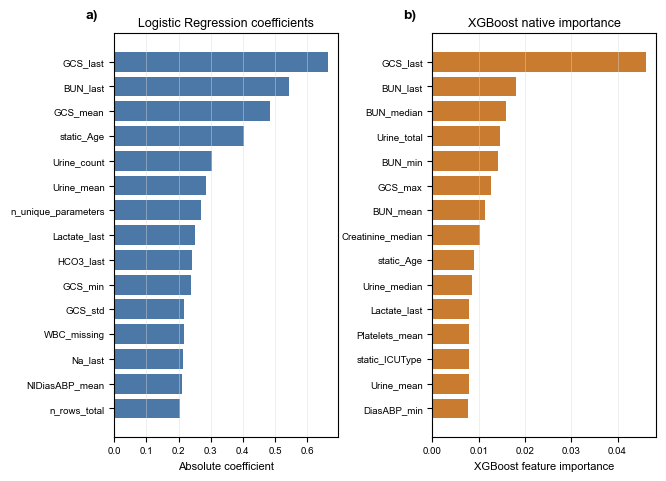

In [7]:

# ============================================================
# 5. Supplementary Figure S3: feature-importance support
# ============================================================

lr_coef_path = RESULTS_DIR / "logistic_regression_standardized_coefficients.csv"
xgb_imp_path = RESULTS_DIR / "xgboost_auc_optimized_native_feature_importance.csv"

if lr_coef_path.exists() and xgb_imp_path.exists():
    lr_df = pd.read_csv(lr_coef_path).sort_values("abs_coefficient", ascending=False).head(15).iloc[::-1]
    xgb_df = pd.read_csv(xgb_imp_path).sort_values("xgb_feature_importance", ascending=False).head(15).iloc[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH_IN, SUPP_FIG_HEIGHT_IN))
    ax1, ax2 = axes

    ax1.barh(lr_df["feature"], lr_df["abs_coefficient"], color=MODEL_COLORS["logistic_regression"], edgecolor="none")
    ax1.set_xlabel("Absolute coefficient")
    ax1.set_title("Logistic Regression coefficients", pad=5)
    style_axis(ax1)
    ax1.grid(True, axis="x", color="#D9D9D9", linewidth=0.5, alpha=0.6)
    ax1.grid(False, axis="y")
    panel_label(ax1, "a)")

    ax2.barh(xgb_df["feature"], xgb_df["xgb_feature_importance"], color=MODEL_COLORS["xgboost_auc_optimized"], edgecolor="none")
    ax2.set_xlabel("XGBoost feature importance")
    ax2.set_title("XGBoost native importance", pad=5)
    style_axis(ax2)
    ax2.grid(True, axis="x", color="#D9D9D9", linewidth=0.5, alpha=0.6)
    ax2.grid(False, axis="y")
    panel_label(ax2, "b)")

    plt.subplots_adjust(left=0.18, right=0.99, top=0.94, bottom=0.10, wspace=0.42)
    supp_stem = "Supplementary_FigureS3_feature_importance_support_170mm"
    save_figure(fig, SUPP_FIG_DIR, supp_stem)
    plt.show()
else:
    print("Required files for Supplementary Figure S3 were not found.")


## Top-30 feature overlap summaries

This notebook now **creates only CSV summaries** for top-30 feature overlap.
It does **not** create an overlap figure.

Saved outputs include:

- pairwise overlap counts and Jaccard scores
- shared feature lists for each pair
- long-format top-30 ranking table


In [8]:
# ============================================================
# 6. Top-30 feature overlap summaries (CSV only)
# ============================================================

feature_sources = []
if lr_coef_path.exists():
    feature_sources.append(("logistic_regression", lr_coef_path, "abs_coefficient"))
if xgb_imp_path.exists():
    feature_sources.append(("xgboost_auc_optimized", xgb_imp_path, "xgb_feature_importance"))

# Optional sources if they exist.
xgb_shap_path = RESULTS_DIR / "xgboost_auc_optimized_mean_abs_shap.csv"
mlp_perm_path = RESULTS_DIR / "mlp_permutation_importance_auc_drop.csv"
if xgb_shap_path.exists():
    feature_sources.append(("xgboost_shap", xgb_shap_path, "mean_abs_shap"))
if mlp_perm_path.exists():
    feature_sources.append(("mlp_permutation", mlp_perm_path, "importance_mean_auc_drop"))

if len(feature_sources) >= 2:
    top_tables = []
    top_sets = {}
    for model_name, path, value_col in feature_sources:
        top = get_top_features(path, value_col, model_name, top_n=TOP_N_OVERLAP)
        top_tables.append(
            top[["model_name", "feature", "rank", value_col, "source_file"]].rename(columns={value_col: "score"})
        )
        top_sets[model_name] = set(top["feature"].astype(str))

    top_long_df = pd.concat(top_tables, ignore_index=True)
    top_long_df.to_csv(SUPP_FIG_DIR / f"top{TOP_N_OVERLAP}_feature_rankings_long.csv", index=False)

    overlap_rows = []
    shared_rows = []
    pair_names = list(top_sets.keys())

    for a, b in itertools.combinations(pair_names, 2):
        shared = sorted(top_sets[a].intersection(top_sets[b]))
        union = sorted(top_sets[a].union(top_sets[b]))
        overlap_rows.append({
            "model_a": a,
            "model_b": b,
            "top_n": TOP_N_OVERLAP,
            "n_overlap": len(shared),
            "jaccard": len(shared) / len(union) if len(union) > 0 else np.nan,
        })

        a_table = top_long_df.loc[top_long_df["model_name"] == a, ["feature", "rank"]].rename(columns={"rank": "rank_a"})
        b_table = top_long_df.loc[top_long_df["model_name"] == b, ["feature", "rank"]].rename(columns={"rank": "rank_b"})
        merged = a_table.merge(b_table, on="feature", how="inner")
        merged["model_a"] = a
        merged["model_b"] = b
        merged["mean_rank"] = merged[["rank_a", "rank_b"]].mean(axis=1)
        merged = merged.sort_values(by=["mean_rank", "rank_a", "rank_b"])
        if not merged.empty:
            shared_rows.append(merged[["model_a", "model_b", "feature", "rank_a", "rank_b", "mean_rank"]])

    overlap_df = pd.DataFrame(overlap_rows)
    overlap_df.to_csv(SUPP_FIG_DIR / f"top{TOP_N_OVERLAP}_overlap_summary.csv", index=False)

    if shared_rows:
        shared_df = pd.concat(shared_rows, ignore_index=True)
        shared_df.to_csv(SUPP_FIG_DIR / f"top{TOP_N_OVERLAP}_shared_features_by_pair.csv", index=False)
    else:
        shared_df = pd.DataFrame(columns=["model_a", "model_b", "feature", "rank_a", "rank_b", "mean_rank"])
        shared_df.to_csv(SUPP_FIG_DIR / f"top{TOP_N_OVERLAP}_shared_features_by_pair.csv", index=False)

    display(overlap_df)
    display(shared_df.head(20))
    print(f"Saved CSV files for top-{TOP_N_OVERLAP} overlap summaries into: {SUPP_FIG_DIR.resolve()}")
else:
    print("Not enough feature-ranking tables were found to compute overlap summaries.")


,model_a,model_b,top_n,n_overlap,jaccard
0,logistic_regression,xgboost_auc_optimized,30,12,0.25


,model_a,model_b,feature,rank_a,rank_b,mean_rank
0,logistic_regression,xgboost_auc_optimized,GCS_last,1,1,1.0
1,logistic_regression,xgboost_auc_optimized,BUN_last,2,2,2.0
2,logistic_regression,xgboost_auc_optimized,static_Age,4,9,6.5
3,logistic_regression,xgboost_auc_optimized,Lactate_last,8,11,9.5
4,logistic_regression,xgboost_auc_optimized,Urine_mean,6,14,10.0
5,logistic_regression,xgboost_auc_optimized,GCS_mean,3,19,11.0
6,logistic_regression,xgboost_auc_optimized,Urine_total,22,4,13.0
7,logistic_regression,xgboost_auc_optimized,Creatinine_median,21,8,14.5
8,logistic_regression,xgboost_auc_optimized,GCS_std,11,27,19.0
9,logistic_regression,xgboost_auc_optimized,PaO2_median,17,30,23.5


Saved CSV files for top-30 overlap summaries into: C:\Users\junse\Documents\research\IUBDC 2026\Supplementary Figures
